<h1>Import Necessary Libraries</h1>

In [4]:
from Road_seg_dataset import helper
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm
import cv2

In [5]:
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Default device:", device)


Default device: cuda


In [7]:
if device.type == "cuda":
    current_idx = torch.cuda.current_device()
    print("CUDA device index:", current_idx)
    print("CUDA device name: ", torch.cuda.get_device_name(current_idx))

CUDA device index: 0
CUDA device name:  NVIDIA GeForce RTX 3060


<h1>CONFIGURATION</h1>

In [8]:
data_csv="F:/Machine learning/Road_seg_dataset/train.csv"
data_dir="F:/Machine learning/Road_seg_dataset/"
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS=25
LEARNING_RATE=0.003
BATCH_SIZE=8
IMG_SIZE=512

ENCODE="timm-efficientnet-b0"
WEIGHTS='imagenet'

In [9]:
df=pd.read_csv(data_csv)
df.head()

,images,masks
0,images/17428750_15.png,masks/17428750_15.png
1,images/23279080_15.png,masks/23279080_15.png
2,images/24179185_15.png,masks/24179185_15.png
3,images/24179035_15.png,masks/24179035_15.png
4,images/11128810_15.png,masks/11128810_15.png


In [10]:
idx=3
row=df.iloc[idx]
image_path=data_dir+row.images
mask_path=data_dir+row.masks

image=cv2.imread(image_path)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
mask=cv2.imread(mask_path)
mask=cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY)/255  #do the /255 one time only for mask

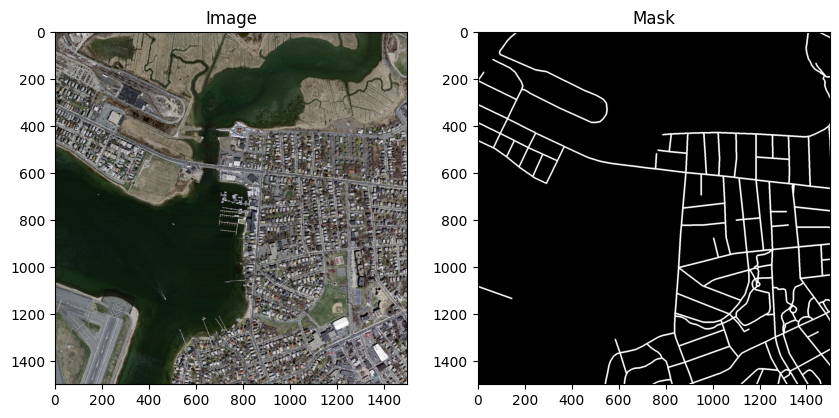

In [11]:
f,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.imshow(image)
ax1.set_title("Image")
ax2.imshow(mask,cmap='gray')
ax2.set_title("Mask")
plt.show()

In [12]:
train_df,val_df=train_test_split(df,test_size=0.2,random_state=42)

In [13]:
train_df.shape,val_df.shape

((159, 2), (40, 2))

<h1>Augmentation</h1>

<h4>Here a library called "Albementation" will be used. It is a well known library for data augmentation. It is very useful for task like object detection, key point detection, classification, and segmentaiton<h4>

In [14]:
import albumentations as A


f:\Machine learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
def get_train_aug():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5)
    ])

def get_valid_aug():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE) # we dont need to augment validation data
    ])

<h5>In segmenation if you want rotate the image then you have to rotate the mask as well.</h5>

<h1>Create Custom Dataset</h1>  

In [16]:
from torch.utils.data import Dataset, DataLoader

class RoadSegDataset(Dataset):
    def __init__(self, df, augmentation):
        self.df = df
        self.augmentation=augmentation
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):

        row=df.iloc[idx]
        image_path=data_dir+row.images
        mask_path=data_dir+row.masks

        image=cv2.imread(image_path)
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        mask=cv2.imread(mask_path)
        mask=cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY) # so now it will be (h,w) pair which hieght and width
        mask=mask/255.0

        mask= np.expand_dims(mask,axis=-1) # so now it will be (h,w,1) pair which hieght and width and channel
        if self.augmentation:
            data=self.augmentation(image=image,mask=mask)
            image=data['image']
            mask=data['mask']
        #pytorch uses (CHANNEL, HEIGHT, WIDTH) format    
        image=np.transpose(image,(2,0,1)).astype(np.float32) #(c,h,w)
        mask=np.transpose(mask,(2,0,1)).astype(np.float32)  #(c,h,w)
        image=torch.tensor(image)/255.0
        mask=torch.round(torch.tensor(mask))
        return image,mask

In [17]:
trainset=RoadSegDataset(train_df,get_train_aug())
valset=RoadSegDataset(val_df,get_valid_aug())

In [18]:
print("Trainset size:",len(trainset))
print("Valset size:",len(valset))

Trainset size: 159
Valset size: 40


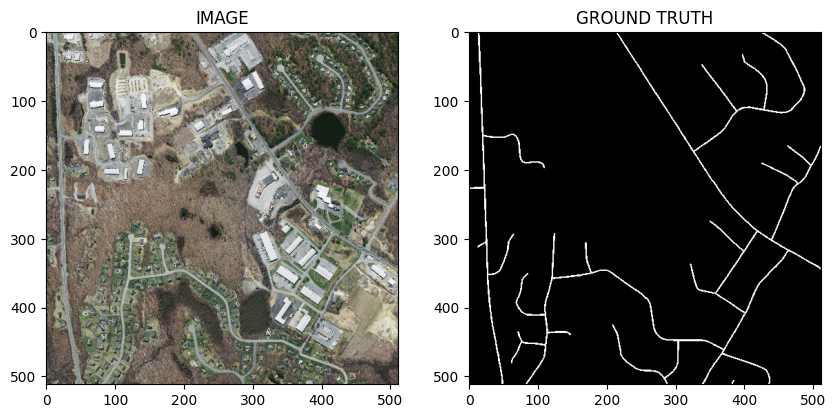

In [19]:
idx=69
image,mask=trainset[idx]
helper.show_image(image,mask)

<h1>Load dataset into Batch</h1>

In [20]:
train_dataloader=DataLoader(trainset,batch_size=BATCH_SIZE,shuffle=True)
val_dataloader=DataLoader(valset,batch_size=BATCH_SIZE,shuffle=False)
print("Train dataloader size:",len(train_dataloader))
print("Val dataloader size:",len(val_dataloader))

Train dataloader size: 20
Val dataloader size: 5


In [21]:
for image,mask in train_dataloader:
    print("Image shape:",image.shape) # (batch_size,channels,height,width) batch_size=8 means it will contain 8 image tensor
    print("Mask shape:",mask.shape)   # (batch_size,channels,height,width)
    break 

Image shape: torch.Size([8, 3, 512, 512])
Mask shape: torch.Size([8, 1, 512, 512])


<h1>Create SEGMENATION MODEL</h1>

In [22]:
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

In [23]:
class SegmentationModel(nn.Module):
    def __init__(self):
        super(SegmentationModel,self).__init__()
        self.backbone=smp.Unet(encoder_name=ENCODE,encoder_weights=WEIGHTS,in_channels=3,classes=1,activation=None)
        #So from this model when we pass the image the output will be logits
        #Logits are the raw output of the model before applying any activation function, if we wish to convert it to probabilities we have to apply activation functions
    
    def forward(self,images,masks=None):
        logits=self.backbone(images)
        if masks is not None:
            return logits,DiceLoss(mode='binary')(logits,masks)+nn.BCEWithLogitsLoss()(logits,masks)
        return logits

In [24]:
model=SegmentationModel().to(device);

<h1>Train and Validation Function</h1>

In [25]:
def train_model(dataloader,model,optimizer):
    model.train()
    total_loss=0
    for images,masks in tqdm(dataloader):
        images=images.to(device)
        masks=masks.to(device)
        optimizer.zero_grad() #zeroing the gradients
        logits,loss=model(images,masks) #getting the logits from the model because we did not use any activation function in model
        loss.backward()
        optimizer.step() #updating the weights and biases
        total_loss+=loss.item()
    return total_loss/len(dataloader) #returning the average loss of the epoch

def eval_model(dataloader,model): #we dont need to pass optimizer in eval model
    model.eval() #turn off dropout and batchnorm etc
    total_loss=0
    with torch.no_grad():
      for images,masks in tqdm(dataloader):
          images=images.to(device)
          masks=masks.to(device)
          logits,loss=model(images,masks) #getting the logits from the model because we did not use any activation function in model
          total_loss+=loss.item()
      return total_loss/len(dataloader) #returning the average loss of the epoch

<h1>Train the model</h1>


In [26]:
optimizer=torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)
best_loss=np.inf
for i in range(EPOCHS):
    print("Epoch:",i+1)
    train_loss=train_model(train_dataloader,model,optimizer)
    val_loss=eval_model(val_dataloader,model)
    print("Train Loss:",train_loss)
    print("Validation Loss:",val_loss)
    if val_loss<best_loss:
        torch.save(model.state_dict(),f"best_model.pt")
        best_loss=val_loss
        print("Model saved")
    print(f"EPOCHS :{i+1}/{EPOCHS} Train Loss: {train_loss:.4f} Validation Loss: {val_loss:.4f}")

Epoch: 1


100%|██████████| 5/5 [00:02<00:00,  2.14it/s]


Train Loss: 1.0399841338396072
Validation Loss: 1.027634084224701
Model saved
EPOCHS :1/25 Train Loss: 1.0400 Validation Loss: 1.0276
Epoch: 2


100%|██████████| 5/5 [00:02<00:00,  2.23it/s]


Train Loss: 0.7882715076208114
Validation Loss: 0.8333925008773804
Model saved
EPOCHS :2/25 Train Loss: 0.7883 Validation Loss: 0.8334
Epoch: 3


...

Train Loss: 0.5730384707450866
Validation Loss: 0.5813740611076355
EPOCHS :23/25 Train Loss: 0.5730 Validation Loss: 0.5814
Epoch: 24


100%|██████████| 5/5 [00:02<00:00,  2.22it/s]


Train Loss: 0.5789964392781257
Validation Loss: 0.5950264632701874
EPOCHS :24/25 Train Loss: 0.5790 Validation Loss: 0.5950
Epoch: 25


100%|██████████| 5/5 [00:02<00:00,  2.21it/s]

Train Loss: 0.575459860265255
Validation Loss: 0.5620155096054077
EPOCHS :25/25 Train Loss: 0.5755 Validation Loss: 0.5620


<h1>INFERENCE</h1>

C:\Users\User\AppData\Local\Temp\ipykernel_14232\3364693976.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


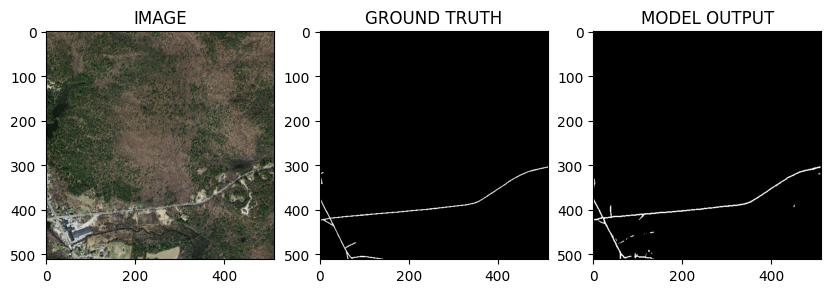

In [27]:
idx=30

model.load_state_dict(torch.load("best_model.pt"))
image,mask=valset[idx]
logits_mask=model(image.to(device).unsqueeze(0)) #we added extra dimension to the image because model expects batch size so (b,c,h,w) format
pred_mask=torch.sigmoid(logits_mask)
pred_mask=(pred_mask>0.5)*1.00 #converting the logits to binary mask

helper.show_image(image,mask,pred_mask.detach().cpu().squeeze(0))

<h1>Test with Unknown Image</h1>

Ignore the Ground Truth here

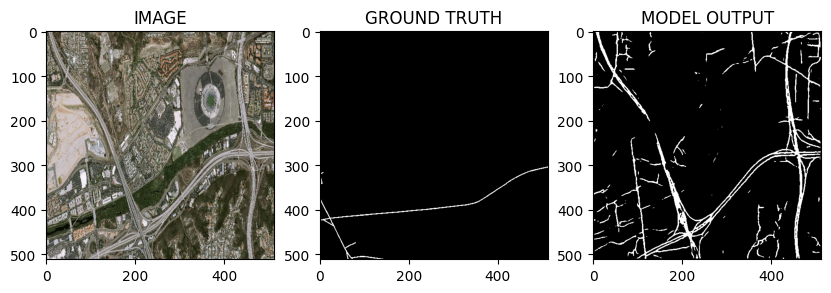

In [35]:
image_path="F:/Machine learning/Road_seg_dataset/ID6_Banner_San_Diego_PHR1B_20150724.png"
image=cv2.imread(image_path)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
image=cv2.resize(image,(IMG_SIZE,IMG_SIZE))
image=torch.tensor(image).permute(2,0,1).unsqueeze(0).to(device)/255.0 # (b,c,h,w) format
image.shape
logits_mask=model(image)
pred_mask=torch.sigmoid(logits_mask)
pred_mask=(pred_mask>0.5)*1.00 #converting the logits to binary mask
helper.show_image(image.squeeze(0).detach().cpu(),mask,pred_mask.detach().cpu().squeeze(0))
